# Caching long running jobs

```{index} Caching ; Joblib
```
In any data science or machine learning pipeline, one often has to re-try and experiment with long running computations. For example, maybe you will be running some long running embeddings for thousands of text segments, or some long running hyperparameter search. In such cases, it is very useful to cache the results of these long running computations so that you don't have to re-run them every time you make a change to your code, just to wait potentially for hours.

This notebook demonstrates how to cache the results of long running computations using the [`joblib`](https://joblib.readthedocs.io/en/stable/) library, which in the long run can save you a lot of time and hassle.

## Why `joblib` ?

`joblib` is a library that provides a simple interface for caching the results of any method call. It is very flexible and can be used to cache the results of methods which take multiple arguments, functions that return multiple values, and functions that return complex objects. There are alternatives to `joblib`, but in all honesty I have found it to be the simplest and quickest to spin-up. Your experience however may vary.

## A simple example

Let's start with a simple example. Suppose you have a function that takes a long time to run, and you want to cache the results of this function. To illustrate this, we will use the [Ulam Spiral](https://mathworld.wolfram.com/PrimeSpiral.html) as an example. The Ulam Spiral is a graphical depiction of the set of prime numbers, where the primes are arranged in a spiral. We will write a function that generates the Ulam Spiral for a given range of numbers, and cache the results of this function.

In [1]:
import numpy as np

# A function which computes all primes between two integers and returns them as a numpy array

def primes_between(a, b):
    sieve = [True] * (b + 1)
    sieve[0] = sieve[1] = False  # 0 and 1 are not prime numbers

    for start in range(2, int(b**0.5) + 1):
        if sieve[start]:
            for multiple in range(start*start, b + 1, start):
                sieve[multiple] = False

    primes = np.array([num for num in range(a, b + 1) if sieve[num]])
    return primes

# Compute the Ulam Spiral and return it as a numpy array

def ulam_spiral(primes, a, b):
    # Calculate the grid size n (smallest odd number greater than or equal to sqrt(b))
    num_elements = b - a + 1
    n = int(np.ceil(np.sqrt(num_elements)))
    if n % 2 == 0:
        n += 1

    # Create an n x n grid
    spiral = np.zeros((n, n), dtype=int)

    # Convert the numpy array of primes to a set for O(1) membership testing
    prime_set = set(primes)

    x, y = n // 2, n // 2  # Start in the center of the grid
    dx, dy = 0, -1         # Initial direction: up

    for i in range(1, n * n + 1):
        if a <= i <= b and i in prime_set:
            spiral[x, y] = 1  # Mark the cell if it's a prime number

        # Change direction if needed
        if (x == y) or (x < y and x + y == n - 1) or (x > y and x + y == n):
            dx, dy = -dy, dx

        x, y = x + dx, y + dy

    return spiral

Running the `primes_between` and `ulam_spiral` generation functions can take significant time for large ranges of $\mathbf{a}$ and $\mathbf{b}$, and the goal is to cache the results of these functions so that you don't have to re-run it every time you make a change to your code. Let's illustrate this with an example of $\mathbf{[1, 500000000]}$.

```{tip}
We will zoom into the Ulam Spiral just to illustrate what it visually looks like, later on we will compute the entire spiral, which will take considerably longer.
```

In [2]:
import time

# Compute all primes
start_time = time.time()
a = 1
b = 500000000
primes = primes_between(a, b)
end_time = time.time()
print(f'Number of primes between {a} and {b}: {len(primes)}')
print("Time taken: ", end_time - start_time)

Number of primes between 1 and 500000000: 26355867
Time taken:  55.70332622528076


Time taken:  1.7404742240905762


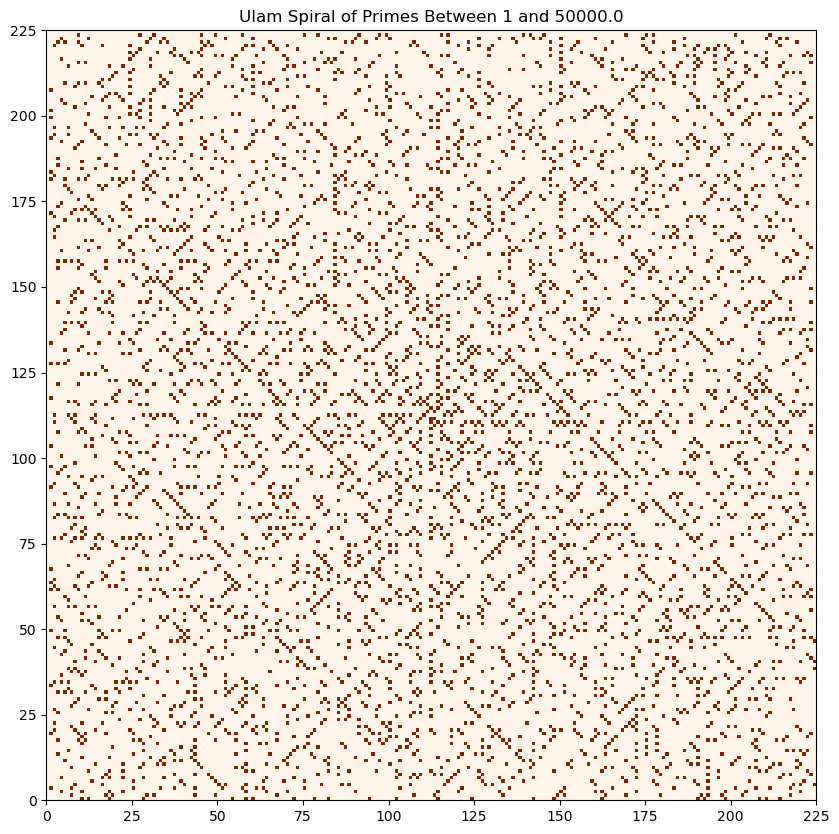

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate Ulam Spiral
start_time = time.time()
zoom_b = b/10000
spiral = ulam_spiral(primes, a, zoom_b)
end_time = time.time()
print("Time taken: ", end_time - start_time)

# Plot Ulam Spiral
plt.figure(figsize=(16, 10))
plt.imshow(spiral, cmap='Oranges', extent=[0, spiral.shape[0], 0, spiral.shape[1]])
plt.title(f'Ulam Spiral of Primes Between {a} and {zoom_b}')
plt.show()

## Wrapping methods with `joblib`

Let us wrap the `ulam_spiral` and `primes_between` methods with joblib's `Memory` class. This will allow us to cache the results, so that we don't have to re-run any given combination of parameters every time we make a change to our code. To do this, we will just use `joblib`'s annotation `@memory.cache` before the method definition.

In [4]:
# Wrap the 'ulam_spiral' method call with joblib's 'Memory' class
from joblib import Memory

memory = Memory(location='/tmp', verbose=0)

@memory.cache
def ulam_spiral_cached(primes, a, b):
    return ulam_spiral(primes, a, b)

@memory.cache
def primes_between_cached(a, b):
    return primes_between(a, b)

In [5]:
# Compute all primes
start_time = time.time()
primes = primes_between_cached(a, b)
end_time = time.time()
print("Time taken: ", end_time - start_time)

# Run it again
start_time = time.time()
primes = primes_between_cached(a, b)
end_time = time.time()
print("Time taken (cached): ", end_time - start_time)

# Generate Ulam Spiral
start_time = time.time()
spiral = ulam_spiral_cached(primes, a, b)
end_time = time.time()
print("Time taken: ", end_time - start_time)

# Run it again
start_time = time.time()
spiral = ulam_spiral_cached(primes, a, b)
end_time = time.time()
print("Time taken (cached): ", end_time - start_time)

Time taken:  55.29279088973999
Time taken (cached):  0.04022073745727539
Time taken:  45.13476586341858
Time taken (cached):  0.8741161823272705


Notice how in the second run, the method is not re-run, and the results are loaded from the cache, significantly reducing the time taken to run the method.

## Special considerations

When using `joblib` to cache the results of a method, there are a few things to keep in mind, or else the caching will not work as expected:

1. The method must be deterministic. That is, the method must return the same output for the same input every time it is run.
2. The method must be serializable. That is, the method must be able to be pickled.
3. The method must not have any side-effects. That is, the method must not modify any global state or have any side-effects.